# SI7011 · Sesión 1 · PyTorch en 60 minutos
## De los tensores a una red multicapa
**Juan David Martínez Vargas · Universidad EAFIT**

Entrenaremos un clasificador lineal y una MLP sobre dos medias lunas. Relacionaremos el código con las ecuaciones de las diapositivas: transformación afín, activación, pérdida, gradiente y actualización.

Adaptación del recorrido de Sebastian Raschka, [PyTorch in One Hour](https://sebastianraschka.com/teaching/pytorch-1h/), con ejemplos y ejercicios propios para SI7011. La hora corresponde al trabajo guiado; las extensiones quedan fuera de ese tiempo. CPU es suficiente y no se descargan datos.

| Intervalo | Trabajo | Minutos |
|---|---|---:|
| 00–05 | Preparación | 5 |
| 05–13 | Tensores y capa lineal | 8 |
| 13–23 | Autograd y un paso de actualización | 10 |
| 23–33 | Datos, lotes y arquitectura | 10 |
| 33–50 | Ciclo de entrenamiento y curvas | 17 |
| 50–60 | Fronteras, evaluación y discusión | 10 |

Ejecuta en orden. Las celdas incluyen resultados de una ejecución de referencia; reinicia el entorno y ejecuta todo para obtener los tuyos. Responde las preguntas breves y conserva las gráficas como evidencia.


## 1. Preparación · 5 min
En Colab o Kaggle normalmente están disponibles los paquetes. Si falla una importación, descomenta la instalación. La práctica usa CPU para evitar configuración adicional.


In [1]:
# Solo si faltan dependencias:
# %pip install torch scikit-learn matplotlib
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
device = torch.device('cpu')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print('PyTorch:', torch.__version__, '| dispositivo:', device)


PyTorch: 2.14.1+cpu | dispositivo: cpu


## 2. Tensores y capa lineal · 8 min
Un lote es una matriz $X\in\mathbb{R}^{B\times d}$. En las diapositivas, cada ejemplo se escribe como vector columna: $z=Wx+b$. PyTorch almacena el lote por filas y calcula:
$$Z=XW^\top+b.$$
`nn.Linear(d, h)` almacena `weight` con forma $(h,d)$ y `bias` con forma $(h,)$. El sesgo se suma a cada fila mediante *broadcasting*.

**Antes de ejecutar:** si el lote contiene tres ejemplos, dos variables y la capa tiene cuatro salidas, ¿qué forma tendrá $Z$?


In [2]:
X_demo = torch.tensor([[1., 2.], [3., 4.], [5., 6.]])
layer = nn.Linear(in_features=2, out_features=4)
Z_demo = X_demo @ layer.weight.T + layer.bias
print('X:', tuple(X_demo.shape))
print('W:', tuple(layer.weight.shape), '| b:', tuple(layer.bias.shape))
print('Z:', tuple(Z_demo.shape))
print('Coincide con nn.Linear:', torch.allclose(Z_demo, layer(X_demo)))
print('Elemento a elemento:', (X_demo * X_demo).shape)
print('Producto matricial:', (X_demo.T @ X_demo).shape)


X: (3, 2)
W: (4, 2) | b: (4,)
Z: (3, 4)
Coincide con nn.Linear: True
Elemento a elemento: torch.Size([3, 2])
Producto matricial: torch.Size([2, 2])


**Respuesta breve:** explica la diferencia entre `*` y `@`, y por qué aparece `.T` en la transformación del lote.

_Escribe aquí._


## 3. Autograd y actualización · 10 min
Primero usamos una regresión de un solo ejemplo para inspeccionar los gradientes:
$$\hat y=wx+b,\qquad L=\tfrac12(\hat y-y)^2.$$
$$\frac{\partial L}{\partial w}=(\hat y-y)x,\qquad \frac{\partial L}{\partial b}=\hat y-y.$$
Después usaremos BCE para clasificación: son dos pérdidas diferentes para dos tareas diferentes.

**Actividad:** con $x=2$, $y=5$, $w=1$ y $b=0$, calcula la predicción, la pérdida y ambos gradientes antes de ejecutar.


In [3]:
x = torch.tensor(2.)
y = torch.tensor(5.)
w = torch.tensor(1., requires_grad=True)
b = torch.tensor(0., requires_grad=True)
y_hat = w*x + b
loss = 0.5*(y_hat-y).square()
loss.backward()
print('Predicción:', y_hat.item(), '| pérdida:', loss.item())
print('Gradiente de w:', w.grad.item(), '| gradiente de b:', b.grad.item())
print('Parámetros después de backward:', w.item(), b.item())


Predicción: 2.0 | pérdida: 4.5
Gradiente de w: -6.0 | gradiente de b: -3.0
Parámetros después de backward: 1.0 0.0


In [4]:
lr = 0.05
with torch.no_grad():
    w -= lr*w.grad
    b -= lr*b.grad
new_loss = 0.5*(w*x+b-y).square()
print('Parámetros actualizados:', w.item(), b.item())
print('Nueva pérdida:', new_loss.item())
w.grad = None
b.grad = None


Parámetros actualizados: 1.2999999523162842 0.15000000596046448
Nueva pérdida: 2.53125


**Respuesta breve:** ¿por qué `backward()` no cambió los parámetros? ¿Qué hace `no_grad()` durante la actualización? ¿Por qué debemos limpiar los gradientes antes de otro paso?

_Escribe aquí._


## 4. Datos, lotes y arquitectura · 10 min
Usaremos las dos medias lunas: una frontera recta no describe bien su separación. La partición es 60 % entrenamiento, 20 % validación y 20 % prueba. Ajustamos el escalador solo con entrenamiento. Validación sirve para comparar; prueba se consulta al final.


Particiones: 720 240 240
Lote: torch.Size([64, 2]) torch.Size([64]) | etiquetas: torch.float32


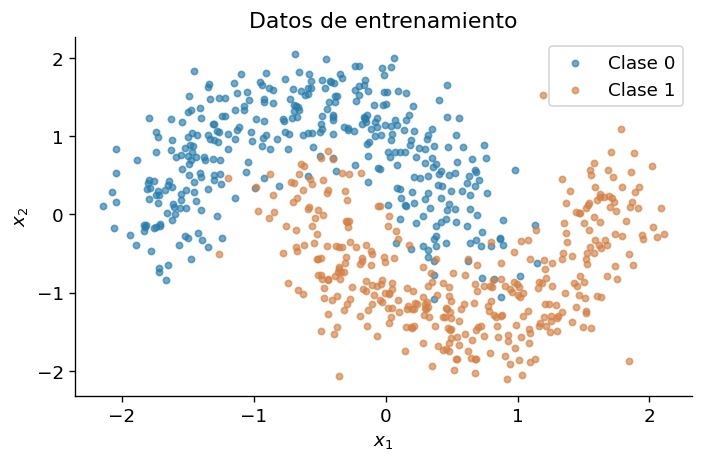

In [5]:
X, y = make_moons(n_samples=1200, noise=0.20, random_state=SEED)
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.50, stratify=y_rest, random_state=SEED)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

def make_dataset(features, labels):
    return TensorDataset(torch.from_numpy(features),
                         torch.tensor(labels, dtype=torch.float32))
train_ds = make_dataset(X_train, y_train)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)
# Cada entrenamiento crea su propio generador para repetir el orden de los lotes.
def training_loader():
    return DataLoader(train_ds, batch_size=64, shuffle=True,
                      generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
xb, yb = next(iter(training_loader()))
print('Particiones:', len(train_ds), len(val_ds), len(test_ds))
print('Lote:', xb.shape, yb.shape, '| etiquetas:', yb.dtype)

fig, ax = plt.subplots(figsize=(6, 4))
for label, color in [(0, '#287dad'), (1, '#d58043')]:
    q = X_train[y_train == label]
    ax.scatter(q[:, 0], q[:, 1], s=14, c=color, alpha=.65, label=f'Clase {label}')
ax.set(xlabel='$x_1$', ylabel='$x_2$', title='Datos de entrenamiento')
ax.legend(); fig.tight_layout(); plt.show()


La MLP usa el mismo recorrido de las figuras:
$$z_1=W_1x+b_1,\quad a_1=\operatorname{ReLU}(z_1),\quad
z_2=W_2a_1+b_2,\quad a_2=\operatorname{ReLU}(z_2),\quad s=W_3a_2+b_3.$$
La salida $s$ es un **logit**. La probabilidad es $p=\operatorname{sigmoid}(s)$; no confundas la sigmoid final con las ReLU ocultas.

`BCEWithLogitsLoss` combina sigmoid y BCE de forma estable. Por eso el modelo termina en `Linear`, sin `Sigmoid`. Para cada ejemplo usamos un logit y una etiqueta flotante 0 o 1, ambos con forma $(B,)$ tras `squeeze(-1)`.


In [6]:
class MLP(nn.Module):
    def __init__(self, hidden=16, nonlinear=True):
        super().__init__()
        activation = nn.ReLU if nonlinear else nn.Identity
        self.layers = nn.Sequential(
            nn.Linear(2, hidden), activation(),
            nn.Linear(hidden, hidden), activation(),
            nn.Linear(hidden, 1))
    def forward(self, x):
        return self.layers(x).squeeze(-1)

torch.manual_seed(SEED)
model = MLP().to(device)
print(model)
print('Parámetros:', sum(p.numel() for p in model.parameters()))
print('Logits del lote:', model(xb).shape)
print('Probabilidades:', torch.sigmoid(model(xb[:3])).detach())


MLP(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
Parámetros: 337
Logits del lote: torch.Size([64])
Probabilidades: tensor([0.4463, 0.4592, 0.4554])


**Actividad:** calcula los parámetros de `Linear(2, 16)`, incluyendo sesgos. ¿Qué ocurre con la familia de funciones si reemplazamos ambas ReLU por `Identity`?

_Escribe aquí._


## 5. Entrenamiento y curvas · 17 min
En cada lote: `zero_grad()` limpia; el forward calcula logits; la pérdida mide el error; `backward()` calcula gradientes; `step()` actualiza parámetros. Usamos SGD como regla de actualización: aplica directamente el paso $\theta \leftarrow \theta-\eta\nabla_\theta L$ que acabamos de estudiar. Momentum y Adam se desarrollan en la siguiente sesión.

Durante validación usamos `eval()` y `no_grad()`. Aquí no hay dropout ni batch normalization, pero conservamos el patrón que necesitaremos en otras arquitecturas.


In [7]:
criterion = nn.BCEWithLogitsLoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    for features, targets in loader:
        features, targets = features.to(device), targets.to(device)
        logits = model(features).reshape(-1)
        loss_sum += criterion(logits, targets).item()*len(targets)
        # sigmoid(logit) >= 0.5 equivale a logit >= 0.
        correct += ((logits >= 0).long() == targets.long()).sum().item()
        total += len(targets)
    return loss_sum/total, correct/total

def fit(model, epochs=60, lr=0.05):
    loader = training_loader()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
    for epoch in range(epochs):
        model.train()
        loss_sum, total = 0., 0
        for features, targets in loader:
            features, targets = features.to(device), targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(features).reshape(-1)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()*len(targets)
            total += len(targets)
        val_loss, val_accuracy = evaluate(model, val_loader)
        history['train_loss'].append(loss_sum/total)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        if (epoch+1) % 20 == 0:
            print(f'Época {epoch+1:2d}: train={loss_sum/total:.3f}, '
                  f'val={val_loss:.3f}, acc_val={val_accuracy:.3f}')
    return history

history = fit(model)


Época 20: train=0.114, val=0.096, acc_val=0.971
Época 40: train=0.094, val=0.088, acc_val=0.971
Época 60: train=0.089, val=0.087, acc_val=0.971


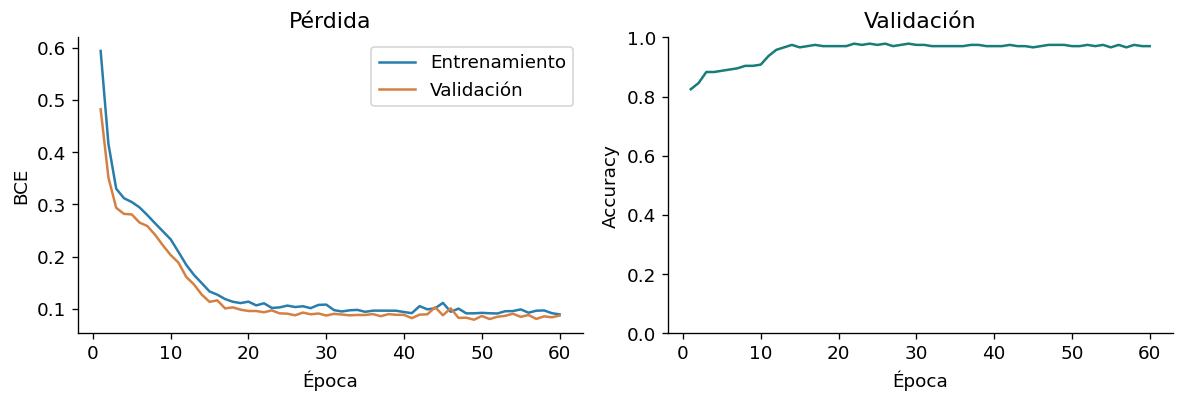

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
epochs = np.arange(1, len(history['train_loss'])+1)
axes[0].plot(epochs, history['train_loss'], label='Entrenamiento', color='#287dad')
axes[0].plot(epochs, history['val_loss'], label='Validación', color='#d58043')
axes[0].set(xlabel='Época', ylabel='BCE', title='Pérdida'); axes[0].legend()
axes[1].plot(epochs, history['val_accuracy'], color='#167d78')
axes[1].set(xlabel='Época', ylabel='Accuracy', ylim=(0, 1), title='Validación')
fig.tight_layout(); plt.show()


**Actividad:** identifica en el ciclo las líneas que corresponden al forward, al backward y a la actualización. Compara las dos pérdidas: la de entrenamiento se promedia mientras cambian los parámetros; la de validación usa los parámetros al final de la época. No son mediciones en el mismo instante.

_Escribe aquí._


## 6. Modelo lineal, fronteras y evaluación · 10 min
Entrenamos el modelo lineal con la misma partición, pérdida, épocas, lotes y optimizador. La comparación cambia la arquitectura. Una sola semilla permite inspeccionar el ejemplo, pero no estima la variabilidad entre ejecuciones.


In [9]:
torch.manual_seed(SEED)
linear_model = nn.Linear(2, 1).to(device)
linear_history = fit(linear_model)
candidates = {'Lineal': linear_model, 'MLP': model}
validation_results = {name: evaluate(candidate, val_loader)
                      for name, candidate in candidates.items()}
print('Modelo    BCE validación    Accuracy validación')
for name, (value, accuracy) in validation_results.items():
    print(f'{name:8s}  {value:.4f}            {accuracy:.3f}')


Época 20: train=0.358, val=0.358, acc_val=0.825
Época 40: train=0.311, val=0.308, acc_val=0.867
Época 60: train=0.302, val=0.297, acc_val=0.867
Modelo    BCE validación    Accuracy validación
Lineal    0.2972            0.867
MLP       0.0871            0.971


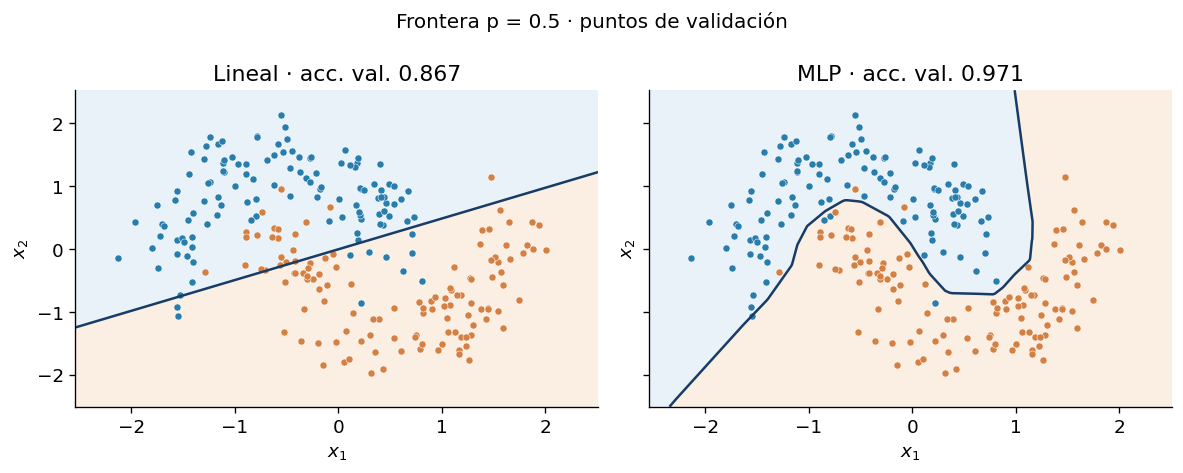

In [10]:
@torch.no_grad()
def plot_boundaries(candidates):
    bounds = np.vstack([X_train, X_val])
    lo, hi = bounds.min(axis=0)-.4, bounds.max(axis=0)+.4
    xx, yy = np.meshgrid(np.linspace(lo[0], hi[0], 220),
                         np.linspace(lo[1], hi[1], 220))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    fig, axes = plt.subplots(1, len(candidates), figsize=(5*len(candidates), 4),
                             sharex=True, sharey=True, squeeze=False)
    for ax, (name, candidate) in zip(axes.flat, candidates.items()):
        candidate.eval()
        p = torch.sigmoid(candidate(grid.to(device)).reshape(-1)).cpu().numpy().reshape(xx.shape)
        ax.contourf(xx, yy, p >= .5, levels=[-.5,.5,1.5],
                    colors=['#e3eff7','#faeadb'], alpha=.8)
        ax.contour(xx, yy, p, levels=[.5], colors=['#183c65'], linewidths=1.5)
        for label, color in [(0, '#287dad'), (1, '#d58043')]:
            q = X_val[y_val == label]
            ax.scatter(q[:,0], q[:,1], s=18, c=color, edgecolors='white', linewidths=.3)
        _, accuracy = validation_results[name]
        ax.set(title=f'{name} · acc. val. {accuracy:.3f}', xlabel='$x_1$', ylabel='$x_2$')
    fig.suptitle('Frontera p = 0.5 · puntos de validación', fontsize=12)
    fig.tight_layout(); plt.show()

plot_boundaries(candidates)


**Antes de consultar prueba:** explica por qué las ReLU permiten una frontera diferente. ¿Una pérdida baja de entrenamiento basta para afirmar que el modelo generaliza? Seleccionaremos el modelo por la menor BCE de validación.

_Escribe aquí._


In [11]:
selected_name = min(validation_results, key=lambda name: validation_results[name][0])
selected_model = candidates[selected_name]
test_loss, test_accuracy = evaluate(selected_model, test_loader)
print('Seleccionado con validación:', selected_name)
print(f'Prueba final: BCE={test_loss:.4f}, accuracy={test_accuracy:.3f}')


Seleccionado con validación: MLP
Prueba final: BCE=0.0647, accuracy=0.963


### Cierre de la hora
Escribe cuatro o cinco líneas que relacionen: **arquitectura → frontera**, **backward → gradientes** y **step → actualización**. Incluye una evidencia de las curvas o fronteras y aclara qué conjunto usaste para seleccionar.

_Escribe aquí._

**Producto:** notebook ejecutado, curvas, comparación lineal/MLP y explicación breve. La práctica es guiada; no añade un nuevo evento evaluativo al curso.


## Extensión opcional · fuera de los 60 minutos
**Ablación:** conserva la profundidad y los parámetros, pero reemplaza las ReLU por `Identity`. Predice qué frontera puede representar esta composición antes de entrenar. No vuelvas a usar prueba para elegir o modificar el modelo; compara este ejercicio con validación.


In [12]:
# Descomenta para ejecutar la extensión después del trabajo guiado.
# torch.manual_seed(SEED)
# model_without_relu = MLP(nonlinear=False).to(device)
# history_without_relu = fit(model_without_relu)
# print('Sin ReLU, validación:', evaluate(model_without_relu, val_loader))


## Referencias
- Sebastian Raschka, [PyTorch in One Hour](https://sebastianraschka.com/teaching/pytorch-1h/): tensores, autograd, redes, DataLoader y entrenamiento. Adaptación propia para SI7011.
- PyTorch, [Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html).
- PyTorch, [BCEWithLogitsLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html).
- PyTorch, [Autograd](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html).
